<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/Asbestos_Leukemia_ForestPlot_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Meta-analysis Forest Plot in R (Colab Compatible)
This notebook performs a random-effects meta-analysis on asbestos exposure and leukemia risk using the `meta` package in R.

In [6]:
# Install required packages (only needed once)
install.packages("meta", dependencies=FALSE, repos='http://cran.r-project.org')
install.packages("metafor")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



pdf 
  2

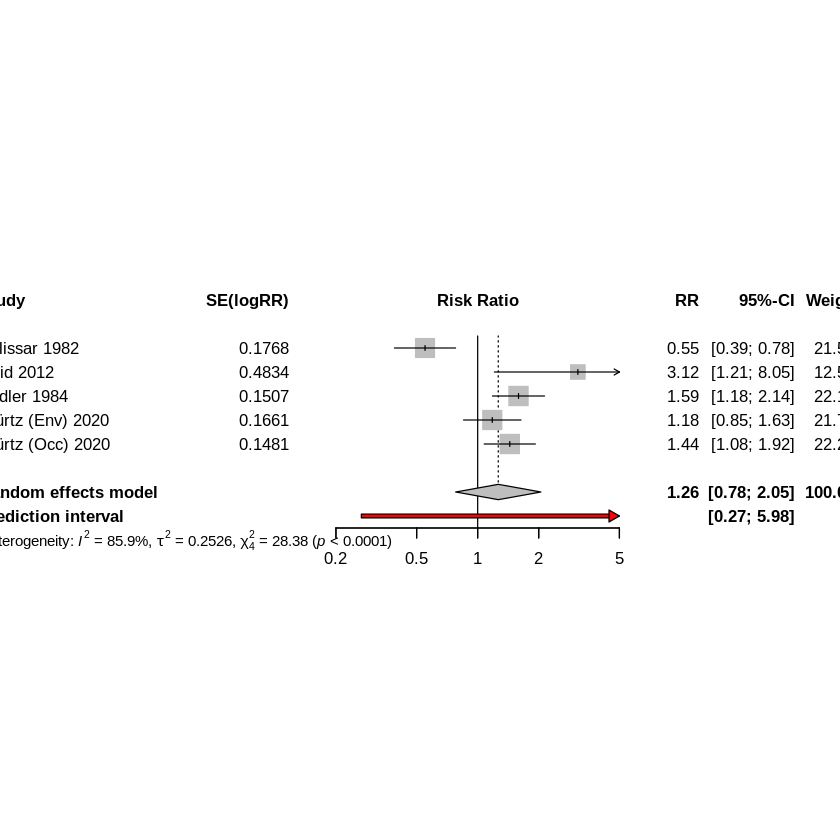

In [10]:
library(meta)

# Data
data <- data.frame(
  Study = c("Polissar 1982", "Reid 2012", "Sadler 1984", "Würtz (Env) 2020", "Würtz (Occ) 2020"),
  RR = c(0.55, 3.12, 1.59, 1.18, 1.44),
  lower = c(0.39, 1.21, 1.18, 0.85, 1.08),
  upper = c(0.78, 8.05, 2.13, 1.63, 1.93)
)

# Compute log(RR) and SE
data$logRR <- log(data$RR)
data$SE <- (log(data$upper) - log(data$lower)) / (2 * 1.96)

# Meta-analysis
m <- metagen(
  TE = data$logRR,
  seTE = data$SE,
  studlab = data$Study,
  sm = "RR",
  random = TRUE,
  common = FALSE
)

# Create forest plot WITHOUT duplicate column names
forest(
  m,
  prediction = TRUE,
  print.tau2 = TRUE,
  print.I2 = TRUE,
  print.Q = TRUE,
  leftcols = c("studlab", "seTE"),
  leftlabs = c("Study", "SE(logRR)"),
  rightcols = c("effect", "ci", "w.random"),
  rightlabs = c("RR", "95%-CI", "Weight"),
  xlim = c(0.2, 5),
  fontsize = 10,
  colgap.studlab = "1cm",
  colgap.forest = "1cm"
)
png("forest_plot_wide.png", width = 2000, height = 1200, res = 200)

forest(
  m,
  prediction = TRUE,
  print.tau2 = TRUE,
  print.I2 = TRUE,
  print.Q = TRUE,
  leftcols = c("studlab", "seTE"),
  leftlabs = c("Study", "SE(logRR)"),
  rightcols = c("effect", "ci", "w.random"),
  rightlabs = c("RR", "95%-CI", "Weight"),
  xlim = c(0.2, 5),
  fontsize = 10,
  colgap.studlab = "2cm",
  colgap.forest = "2cm"
)

dev.off()


Warning message:
“Number of studies (k=5) too small to test for small study effects (k.min=10). Change argument 'k.min' if appropriate.”


                        RR           95%-CI %W(random)
Polissar 1982       0.5500 [0.3889; 0.7778]       15.7
Reid 2012           3.1200 [1.2096; 8.0473]       10.0
Sadler 1984         1.5900 [1.1835; 2.1362]       16.1
Würtz (Env) 2020    1.1800 [0.8521; 1.6340]       15.9
Würtz (Occ) 2020    1.4400 [1.0772; 1.9250]       16.2
Filled: Sadler 1984 0.6689 [0.4978; 0.8986]       16.1
Filled: Reid 2012   0.3409 [0.1322; 0.8792]       10.0

Number of studies: k = 7 (with 2 added studies)

                         RR           95%-CI    z p-value
Random effects model 1.0073 [0.6348; 1.5984] 0.03  0.9754

Quantifying heterogeneity (with 95%-CIs):
 tau^2 = 0.3216 [0.1000; 2.5301]; tau = 0.5671 [0.3162; 1.5906]
 I^2 = 86.8% [75.0%; 93.0%]; H = 2.75 [2.00; 3.78]

Test of heterogeneity:
     Q d.f.  p-value
 45.38    6 < 0.0001

Details of meta-analysis methods:
- Inverse variance method
- Restricted maximum-likelihood estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and t

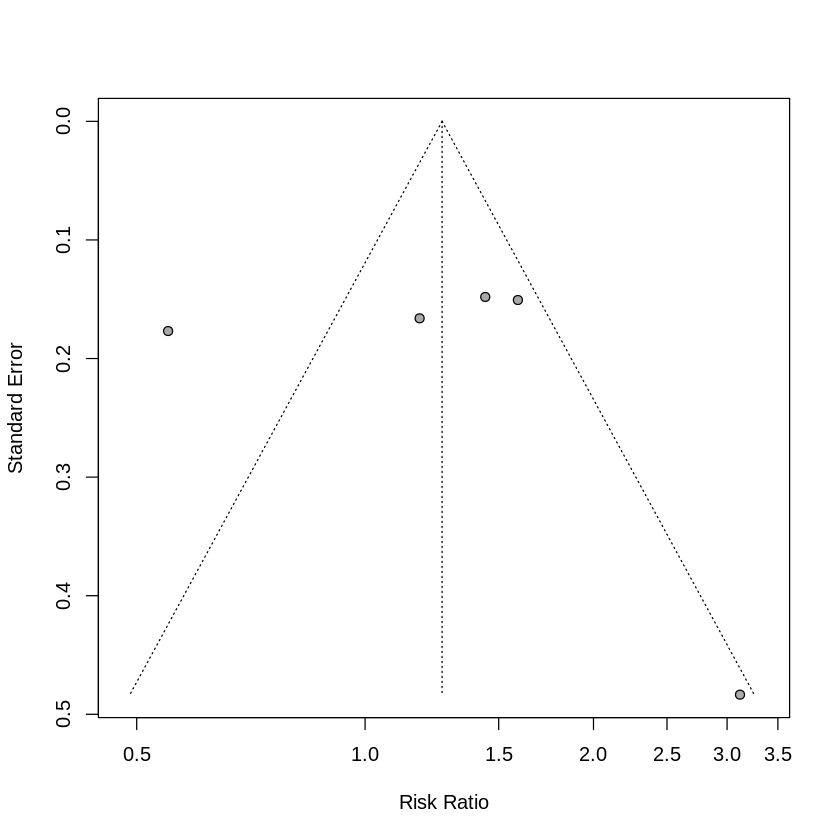

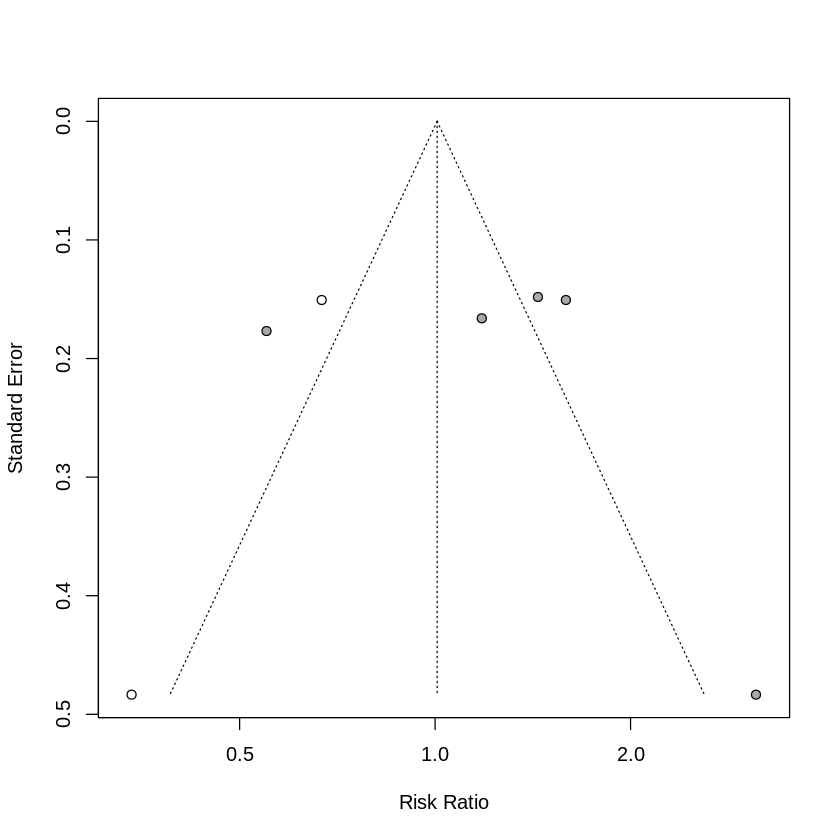

In [11]:
# Load required package
library(meta)

# Your data
data <- data.frame(
  Study = c("Polissar 1982", "Reid 2012", "Sadler 1984", "Würtz (Env) 2020", "Würtz (Occ) 2020"),
  RR = c(0.55, 3.12, 1.59, 1.18, 1.44),
  lower = c(0.39, 1.21, 1.18, 0.85, 1.08),
  upper = c(0.78, 8.05, 2.13, 1.63, 1.93)
)

data$logRR <- log(data$RR)
data$SE <- (log(data$upper) - log(data$lower)) / (2 * 1.96)

# Meta-analysis object
m <- metagen(
  TE = data$logRR,
  seTE = data$SE,
  studlab = data$Study,
  sm = "RR",
  random = TRUE,
  common = FALSE
)

# Basic funnel plot
funnel(m)

# Egger’s test
metabias(m, method.bias = "linreg")

# Trim-and-fill estimate
tf <- trimfill(m)
summary(tf)

# Funnel plot with filled studies (if any)
funnel(tf)


Loading required package: Matrix

Loading required package: numDeriv


Loading the 'metafor' package (version 4.8-0). For an
introduction to the package please type: help(metafor)




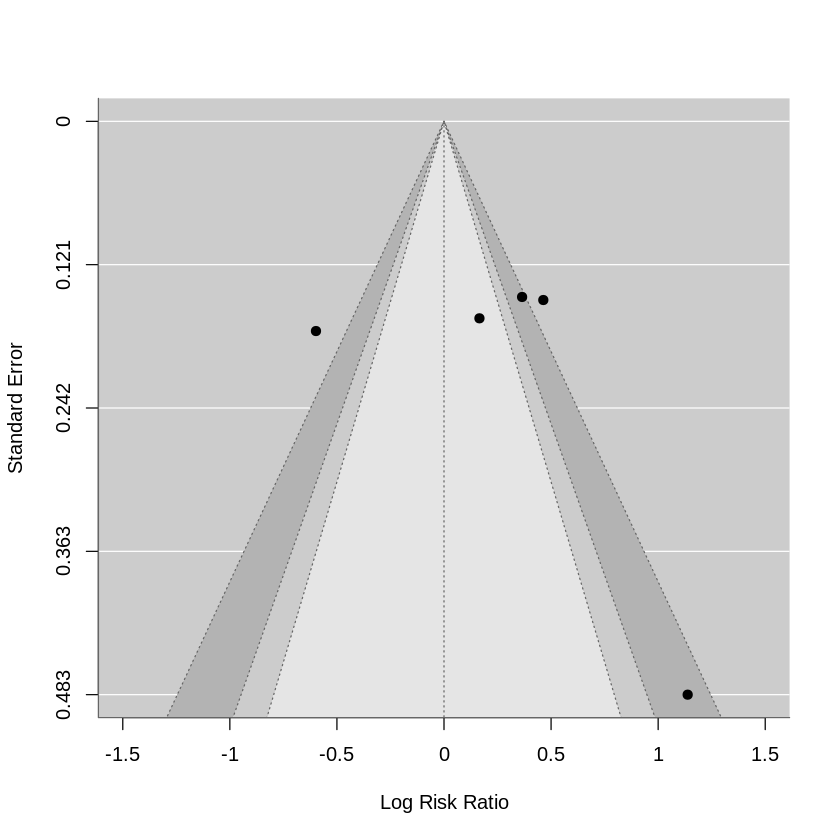

In [12]:
library(metafor)

# Data setup
logRR <- log(c(0.55, 3.12, 1.59, 1.18, 1.44))
sei <- (log(c(0.78, 8.05, 2.13, 1.63, 1.93)) - log(c(0.39, 1.21, 1.18, 0.85, 1.08))) / (2 * 1.96)
study_labels <- c("Polissar 1982", "Reid 2012", "Sadler 1984", "Würtz (Env) 2020", "Würtz (Occ) 2020")

# Run random-effects meta-analysis
res <- rma(yi = logRR, sei = sei, method = "REML")

# Contour-enhanced funnel plot
funnel(res,
       xlab = "Log Risk Ratio",
       ylab = "Standard Error",
       level = c(0.90, 0.95, 0.99),
       shade = c("gray90", "gray80", "gray70"),
       refline = 0,
       pch = 19,
       slab = study_labels)


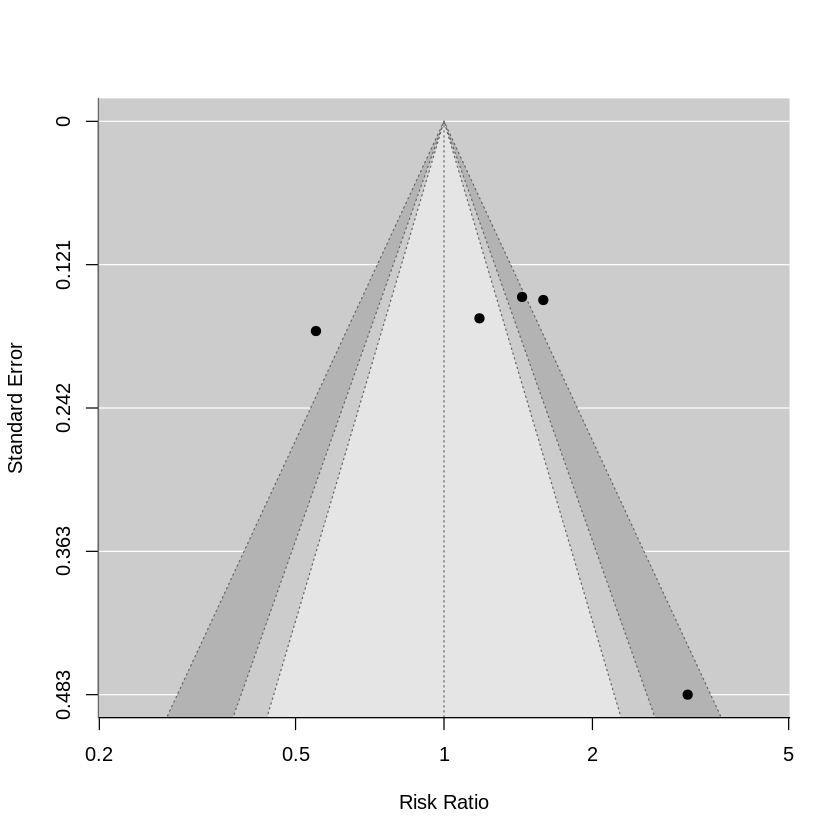

In [13]:
library(metafor)

# Original data in RR and 95% CI
RR <- c(0.55, 3.12, 1.59, 1.18, 1.44)
lower <- c(0.39, 1.21, 1.18, 0.85, 1.08)
upper <- c(0.78, 8.05, 2.13, 1.63, 1.93)
study_labels <- c("Polissar 1982", "Reid 2012", "Sadler 1984", "Würtz (Env) 2020", "Würtz (Occ) 2020")

# Convert to log scale for analysis
logRR <- log(RR)
sei <- (log(upper) - log(lower)) / (2 * 1.96)

# Meta-analysis (random effects)
res <- rma(yi = logRR, sei = sei, method = "REML")

# Funnel plot with custom x-axis labels in RR scale
funnel(res,
       xlab = "Risk Ratio",
       ylab = "Standard Error",
       level = c(0.90, 0.95, 0.99),
       shade = c("gray90", "gray80", "gray70"),
       refline = 0,
       pch = 19,
       slab = study_labels,
       xaxt = "n")  # Disable default axis ticks

# Manually add axis in original RR scale
log_ticks <- log(c(0.2, 0.5, 1, 2, 5, 10))
axis(1, at = log_ticks, labels = c("0.2", "0.5", "1", "2", "5", "10"))


In [14]:
# Install if not already done
install.packages("metafor")

# Load package
library(metafor)

# Your data
RR <- c(0.55, 3.12, 1.59, 1.18, 1.44)
lower <- c(0.39, 1.21, 1.18, 0.85, 1.08)
upper <- c(0.78, 8.05, 2.13, 1.63, 1.93)
logRR <- log(RR)
sei <- (log(upper) - log(lower)) / (2 * 1.96)
study_labels <- c("Polissar 1982", "Reid 2012", "Sadler 1984", "Würtz (Env) 2020", "Würtz (Occ) 2020")

# Run meta-analysis
res <- rma(yi = logRR, sei = sei, method = "REML")

# Open PNG device (wider)
png("contour_funnel_plot.png", width = 2000, height = 1600, res = 300)

# Plot contour-enhanced funnel
funnel(res,
       level = c(0.90, 0.95, 0.99),
       shade = c("gray90", "gray80", "gray70"),
       refline = 0,
       xlab = "Log Risk Ratio",
       ylab = "Standard Error",
       slab = study_labels,
       pch = 19,
       main = "Contour-Enhanced Funnel Plot: Asbestos & Leukemia Risk")

dev.off()


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



pdf 
  2